# GPGN268 - Geophysical Data Analysis
## Data Story 01 - Well Logging

**Student:** Gigi Albers   
**Date: April 6, 2026**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def load_well_log(file):
    df = pd.read_csv(file, skiprows=4)   # skip metadata
    df = df.iloc[1:].reset_index(drop=True)  # drop units row
    df = df.apply(pd.to_numeric, errors='coerce')  # force numeric
    return df

In [4]:
df_cali_nscope = load_well_log("372-U1517A_cali-nscope.csv")
df_gr_gvr = load_well_log("372-U1517A_gr-gvr.csv")
df_gr_scope = load_well_log("372-U1517A_gr-nscope.csv")
df_den_nscope = load_well_log("372-U1517A_den-nscope.csv")
df_por_nscope = load_well_log("372-U1517A_por-nscope.csv")
df_res_gvr = load_well_log("372-U1517A_res-gvr.csv")
df_res_phase_nscope = load_well_log("372-U1517A_res-phase-nscope.csv")
df_res_atten_nscope = load_well_log("372-U1517A_res-atten-nscope.csv")
df_vel_nscope = load_well_log("372-U1517A_vel-sscope.csv")

In [91]:
# --- Step 1: Select columns AND set depth as index ---
df_cali   = df_cali_nscope[["DEPTH_LSF", "UCAV"]].set_index("DEPTH_LSF")
df_gr_rab = df_gr_gvr[["DEPTH_LSF", "GR_RAB"]].set_index("DEPTH_LSF")
df_grma   = df_gr_scope[["DEPTH_LSF", "GRMA"]].set_index("DEPTH_LSF")
df_rhon   = df_den_nscope[["DEPTH_LSF", "RHON"]].set_index("DEPTH_LSF")
df_por    = df_por_nscope[["DEPTH_LSF", "BPHI", "TNPH"]].set_index("DEPTH_LSF")
df_res    = df_res_gvr[["DEPTH_LSF", "RES_BD"]].set_index("DEPTH_LSF")
df_phase  = df_res_phase_nscope[["DEPTH_LSF", "P16B"]].set_index("DEPTH_LSF")
df_atten  = df_res_atten_nscope[["DEPTH_LSF", "A40B"]].set_index("DEPTH_LSF")
df_vel    = df_vel_nscope[["DEPTH_LSF", "VSH", "VCO"]].set_index("DEPTH_LSF")

combined = pd.concat(
    [df_cali, df_gr_rab, df_grma, df_rhon, df_por, df_res, df_phase, df_atten, df_vel],
    axis=1)
combined = combined.sort_index()
combined = combined.interpolate()
combined = combined.reset_index()
combined = combined.apply(pd.to_numeric, errors='coerce')
combined["VSH"] = combined["VSH"].replace(-999.25, np.nan)
combined["VCO"] = combined["VCO"].replace(-999.25, np.nan)
combined["VCO"] = combined["VCO"] * 1000

combined["VSH"] = pd.to_numeric(combined["VSH"], errors='coerce')
combined["VSH"] = combined["VSH"].replace(-999.25, np.nan)
combined.loc[combined["VSH"] < 0, "VSH"] = np.nan
combined["VSH"] = combined["VSH"] * 1000
combined["VSH"] = combined["VSH"].interpolate()
combined.to_csv("data_processed/well_log_processed.csv", index=False)

print("VSH range:", combined["VSH"].min(), combined["VSH"].max())
print("NaNs remaining:", combined["VSH"].isna().sum())
combined[["VCO", "VSH"]] = combined[["VCO", "VSH"]].interpolate()

# --- Step 6: Quick sanity check ---
print(combined[["VCO", "VSH"]].isna().sum())
print(combined.head())
df_combined = [df_cali, df_gr_rab, df_grma, df_rhon, df_por, df_res, df_phase, df_atten, df_vel]

VSH range: 349.5 466.6
NaNs remaining: 4207
VCO       1
VSH    4207
dtype: int64
   DEPTH_LSF  UCAV    GR_RAB  GRMA  RHON  BPHI  TNPH  RES_BD  P16B  A40B  VSH  \
0     0.0129   NaN  5.399876   NaN   NaN   NaN   NaN     NaN   NaN   NaN  NaN   
1     0.0332   NaN  5.672213   NaN   NaN   NaN   NaN     NaN   NaN   NaN  NaN   
2     0.0434   NaN  5.944551   NaN   NaN   NaN   NaN     NaN   NaN   NaN  NaN   
3     0.0739   NaN  6.488374   NaN   NaN   NaN   NaN     NaN   NaN   NaN  NaN   
4     0.1044   NaN  7.031960   NaN   NaN   NaN   NaN     NaN   NaN   NaN  NaN   

       VCO  
0      NaN  
1  1473.20  
2  1472.65  
3  1472.10  
4  1471.55  


In [86]:
print(combined["VSH"].min(), combined["VSH"].max())
print(combined["VSH"].isna().sum(), "/", len(combined))

349.5 466.6
4207 / 7994


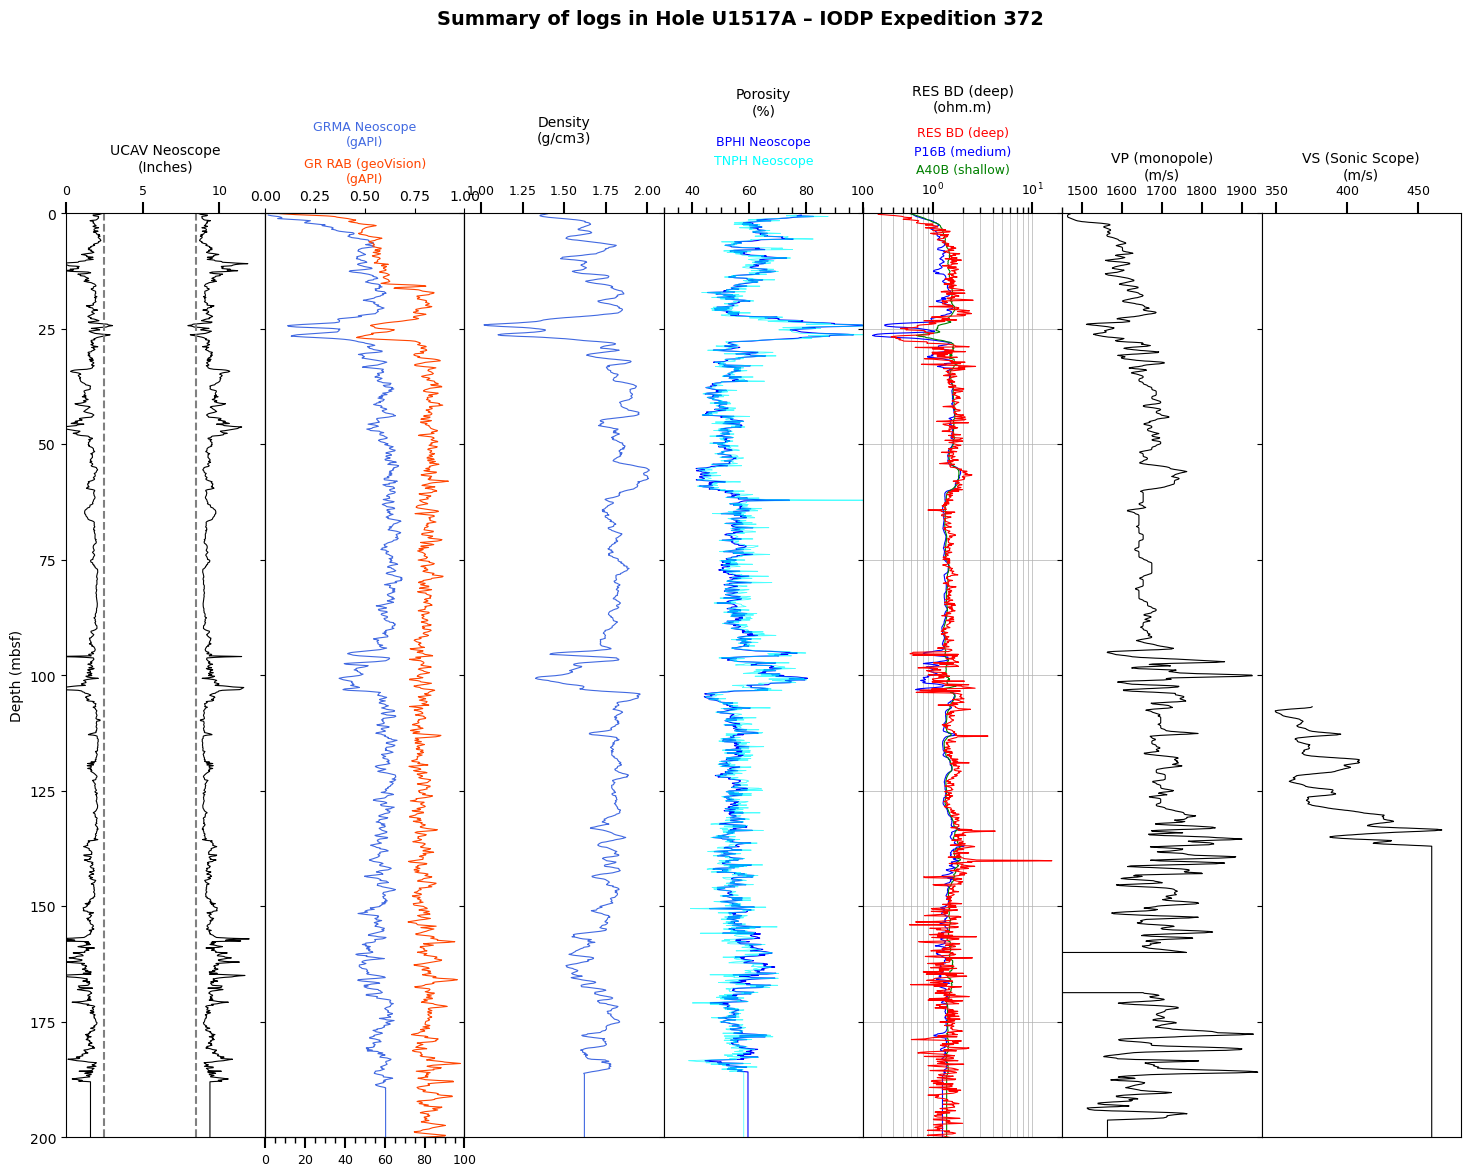

In [87]:
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(18, 12), sharey=True)
plt.subplots_adjust(wspace=0) # Narrow space between tracks

# Common settings for all tracks
for ax in axes:
    ax.invert_yaxis()
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.margins(0)
    ax.set_ylim(combined["DEPTH_LSF"].max(), combined["DEPTH_LSF"].min())
    ax.set_ylim(200, 0)
    ax.tick_params(axis='x', labelsize=8)
    #ax.set_xlim(0, 200)  # force all tracks to 0–200
    ax.tick_params(axis='x', which='major', length=8, width=1.5, labelsize=9)
    ax.set_xticks(range(0, 201, 5), minor=True)
    ax.tick_params(axis='x', which='minor', length=4, width=1)

#axes[0].set_ylabel("Depth (mbsf)")

# --- Track 1: Hole Size (UCAV) ---
#axes[0].plot(combined["UCAV"], combined["DEPTH_LSF"], color='black', lw=0.8)
axes[0].set_xlabel("UCAV Neoscope\n(Inches)", labelpad = 10)
axes[0].set_xlim(0, 13)
#axes[0].plot(combined["UCAV"], combined["DEPTH_LSF"], color='black', lw=0.8)
axes[0].set_xlim(0, 13)
center = 11 / 2
ucav = combined["UCAV"]
axes[0].plot(ucav, combined["DEPTH_LSF"], color='black', lw=0.8)
axes[0].plot(2*center - ucav, combined["DEPTH_LSF"], color='black', lw=0.8)
bit_size = 8.5
mirror = 2*center - bit_size
axes[0].axvline(x=bit_size, color='gray', linestyle='--')
axes[0].axvline(x=mirror, color='gray', linestyle='--')



# --- Track 2: Gamma Ray (GRMA & GR_RAB) ---
axes[1].plot(combined["GRMA"], combined["DEPTH_LSF"], color='royalblue', lw=0.8, label='GRMA')
ax2_top = axes[1].twiny() # If you want two scales, otherwise just plot on same ax
axes[1].plot(combined["GR_RAB"], combined["DEPTH_LSF"], color='orangered', lw=0.8, label='GR_RAB')
axes[1].text(0.5, 1.07, "GRMA Neoscope\n(gAPI)", color='royalblue', transform=axes[1].transAxes, ha='center', va='bottom', fontsize=9)
axes[1].text(0.5, 1.03, "GR RAB (geoVision)\n(gAPI)", color='orangered', transform=axes[1].transAxes, ha='center', va='bottom', fontsize=9)
axes[1].set_xlim(0, 100)

# --- Track 3: Density (RHON) ---
axes[2].plot(combined["RHON"], combined["DEPTH_LSF"], color='royalblue', lw=0.8)
axes[2].set_xlabel("Density\n(g/cm3)", labelpad = 30)
axes[2].set_xlim(0.9, 2.1)

# --- Track 4: Porosity (BPHI & TNPH) ---
axes[3].plot(combined["BPHI"], combined["DEPTH_LSF"], color='blue', lw=0.8)
axes[3].plot(combined["TNPH"], combined["DEPTH_LSF"], color='cyan', lw=0.6, alpha=0.7)
axes[3].text(0.5, 1.07, "BPHI Neoscope", color='blue', transform=axes[3].transAxes, ha='center', va='bottom', fontsize=9)
axes[3].text(0.5, 1.05, "TNPH Neoscope", color='cyan', transform=axes[3].transAxes, ha='center', va='bottom', fontsize=9)
axes[3].set_xlabel("Porosity\n(%)", labelpad = 50)
axes[3].set_xlim(100, 30)
axes[3].invert_xaxis() # Porosity often plotted high-to-low

# --- Track 5: Resistivity (P16B & A40B) ---
# Resistivity is usually Logarithmic!
axes[4].plot(combined["P16B"], combined["DEPTH_LSF"], color='blue', lw=0.8)
axes[4].plot(combined["A40B"], combined["DEPTH_LSF"], color='green', lw=0.8)
axes[4].plot(combined["RES_BD"], combined["DEPTH_LSF"], color='red', lw=0.8)
axes[4].set_xlabel("RES BD (deep)\n(ohm.m)", labelpad = 50)
axes[4].text(0.5, 1.08, "RES BD (deep)", color='red', transform=axes[4].transAxes, ha='center', va='bottom', fontsize=9)
axes[4].text(0.5, 1.06, "P16B (medium)", color='blue', transform=axes[4].transAxes, ha='center', va='bottom', fontsize=9)
axes[4].text(0.5, 1.04, "A40B (shallow)", color='green', transform=axes[4].transAxes, ha='center', va='bottom', fontsize=9)
axes[4].set_xscale('log')
axes[4].set_xlim(0.2, 20)
axes[4].grid(True, which='both', lw=0.5)

# --- Track 6: Vp (P-Wave Velocity) ---
# Assuming VCO or similar is your Vp
axes[5].plot(combined["VCO"], combined["DEPTH_LSF"], color='black', lw=0.8)
axes[5].set_xlabel("VP (monopole)\n(m/s)")
axes[5].set_xlim(1450, 1950)

# --- Track 7: Vs (S-Wave Velocity) ---
# Assuming VSH or similar is your Vs
axes[6].plot(combined["VSH"], combined["DEPTH_LSF"], color='black', lw=0.8)
axes[6].set_xlabel("VS (Sonic Scope)\n(m/s)")
axes[6].set_xlim(340, 480)

# Set Depth Label
axes[0].set_ylabel("Depth (mbsf)")

plt.suptitle("Summary of logs in Hole U1517A – IODP Expedition 372", y=1.05, fontsize=14, fontweight='bold')
plt.show()

In [66]:
print(combined["VCO"].isna().sum(), "/", len(combined))
print(combined["VSH"].isna().sum(), "/", len(combined))

5416 / 6705
5416 / 6705
